In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# --- File and Channel Configuration ---
H5_FILE_PATH = 'SIGNAL.h5'
CHANNEL_1 = 'LTA3'
CHANNEL_2 = 'LTA4'

# --- Load the data ---
try:
    with h5py.File(H5_FILE_PATH, 'r') as f:
        # Navigate to datasets
        signals = f['data/Signals'][:]
        time = f['data/Time'][:]
        
        # Load and decode channel names
        channel_names_raw = f['metadata/channel_names'][:]
        channel_names = [name.decode('utf-8') for name in channel_names_raw]
        
        print("File loaded successfully.")
        print(f"Signal data shape: {signals.shape}")
        print(f"Time vector length: {len(time)}")
        print(f"Number of channels: {len(channel_names)}")

except FileNotFoundError:
    print(f"Error: The file '{H5_FILE_PATH}' was not found.")
    print("Please make sure your .h5 file is in the same directory as the notebook.")

File loaded successfully.
Signal data shape: (97, 7412096)
Time vector length: 7412096
Number of channels: 97


In [3]:
# --- Find indices of the target channels ---
try:
    idx_lta3 = channel_names.index(CHANNEL_1)
    idx_lta4 = channel_names.index(CHANNEL_2)
    print(f"Found '{CHANNEL_1}' at index: {idx_lta3}")
    print(f"Found '{CHANNEL_2}' at index: {idx_lta4}")

    # --- Create the bipolar channel signal ---
    bipolar_signal = signals[idx_lta3, :] - signals[idx_lta4, :]
    print("Bipolar channel 'LTA3-LTA4' created.")

    # --- Define time windows based on your data ---
    # E1: AD Start ToD to Start of Questioning
    e1_start_s, e1_end_s = 2500.12, 2570.00

    # E2: Start of Questioning to End of AD ToD
    e2_start_s, e2_end_s = 2570.00, 2575.00
    
    print(f"\nWindow E1 defined: {e1_start_s}s to {e1_end_s}s")
    print(f"Window E2 defined: {e2_start_s}s to {e2_end_s}s")

except ValueError as e:
    print(f"Error: A specified channel was not found in the file. Details: {e}")
except NameError:
    print("Error: Could not process data. Was the file loaded correctly in the previous step?")

Found 'LTA3' at index: 40
Found 'LTA4' at index: 41
Bipolar channel 'LTA3-LTA4' created.

Window E1 defined: 2500.12s to 2570.0s
Window E2 defined: 2570.0s to 2575.0s


In [4]:
try:
    # --- Find indices for Window E1 ---
    e1_indices = np.where((time >= e1_start_s) & (time <= e1_end_s))
    e1_time = time[e1_indices]
    e1_signal = bipolar_signal[e1_indices]

    # --- Find indices for Window E2 ---
    e2_indices = np.where((time >= e2_start_s) & (time <= e2_end_s))
    e2_time = time[e2_indices]
    e2_signal = bipolar_signal[e2_indices]

    print(f"Extracted {len(e1_signal)} data points for Window E1.")
    print(f"Extracted {len(e2_signal)} data points for Window E2.")

except NameError:
    print("Error: Could not slice data. Ensure the previous cells ran without error.")

Extracted 69881 data points for Window E1.
Extracted 5001 data points for Window E2.


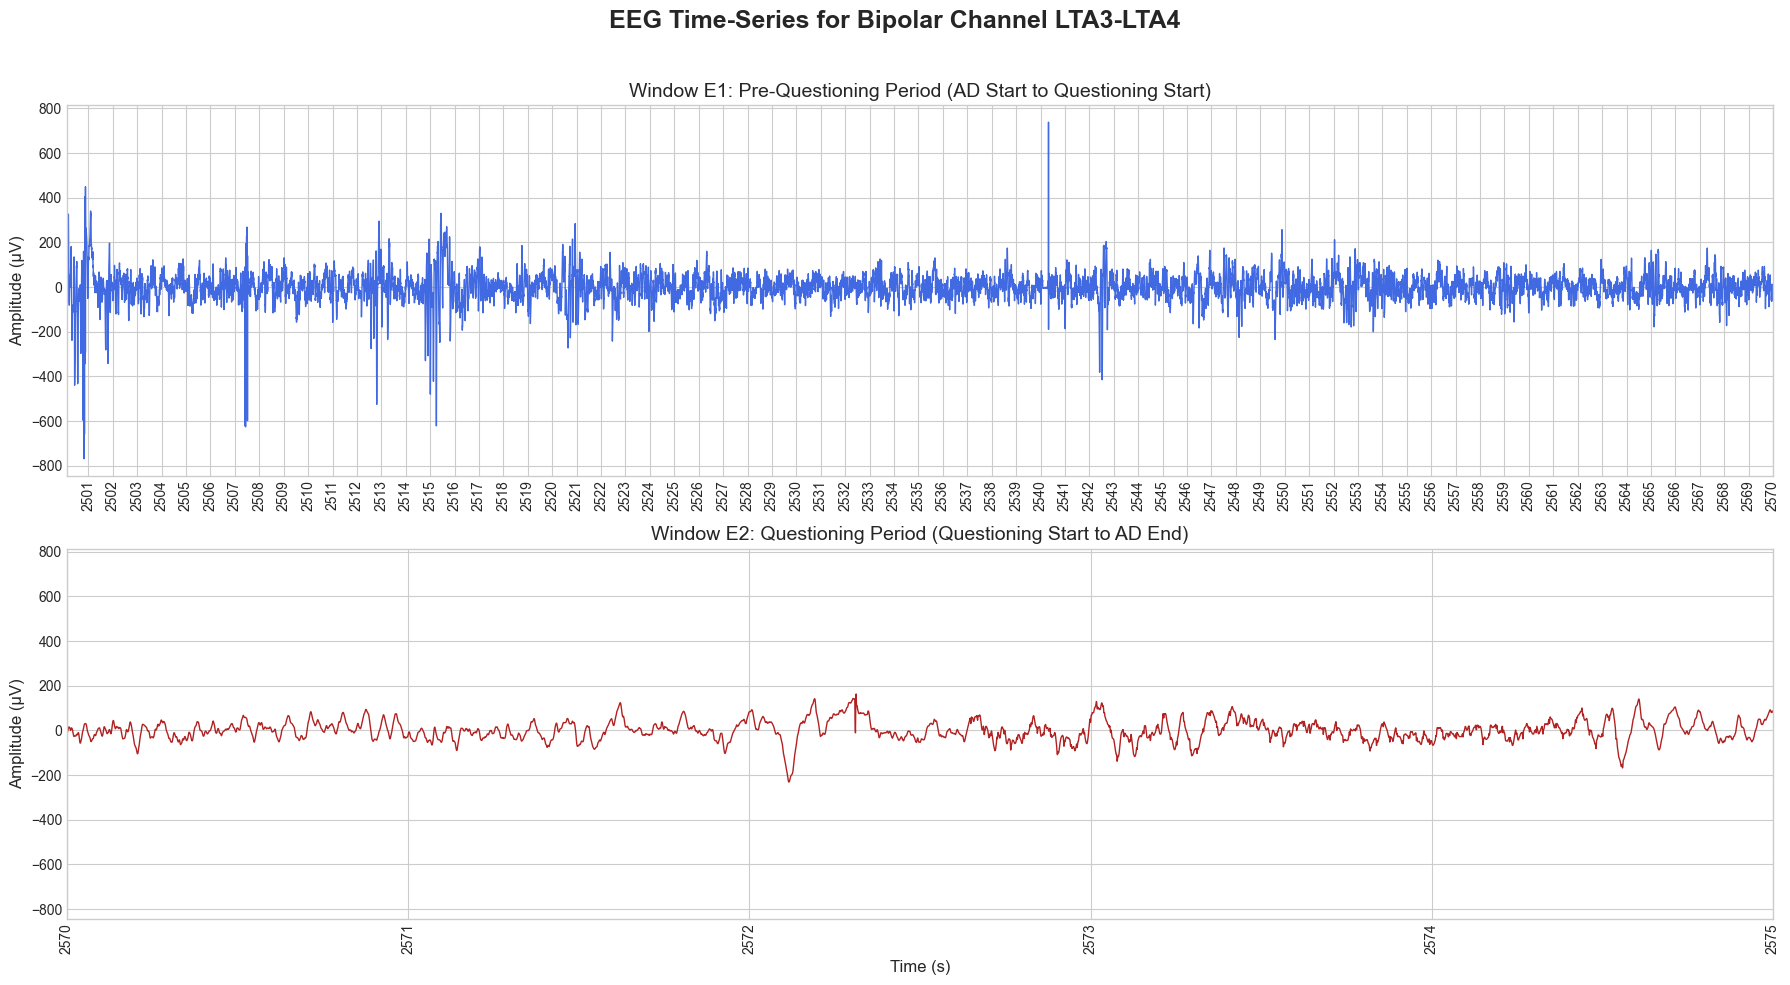

In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker # Import the ticker module

try:
    # Set a professional plot style
    plt.style.use('seaborn-v0_8-whitegrid')

    # Create a figure with two subplots, arranged vertically
    fig, (ax1, ax2) = plt.subplots(
        nrows=2, 
        ncols=1, 
        figsize=(18, 10), # Adjusted figure size for better label visibility
        sharex=False, 
        sharey=True   
    )

    # --- Plot for Window E1 ---
    ax1.plot(e1_time, e1_signal, color='royalblue', linewidth=1)
    ax1.set_title('Window E1: Pre-Questioning Period (AD Start to Questioning Start)', fontsize=14)
    ax1.set_ylabel('Amplitude (µV)', fontsize=12) 
    ax1.set_xlim(e1_start_s, e1_end_s) 
    
    # === Apply formatting to the E1 plot (ax1) ===
    ax1.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax1.tick_params(axis='x', rotation=90, labelsize=10)


    # --- Plot for Window E2 ---
    ax2.plot(e2_time, e2_signal, color='firebrick', linewidth=1)
    ax2.set_title('Window E2: Questioning Period (Questioning Start to AD End)', fontsize=14)
    ax2.set_xlabel('Time (s)', fontsize=12)
    ax2.set_ylabel('Amplitude (µV)', fontsize=12)
    ax2.set_xlim(e2_start_s, e2_end_s) 

    # === Apply formatting to the E2 plot (ax2) ===
    ax2.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax2.tick_params(axis='x', rotation=90, labelsize=10)
    
    # --- Final Touches ---
    fig.suptitle('EEG Time-Series for Bipolar Channel LTA3-LTA4', fontsize=18, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96]) 
    
    # Save the figure
    plt.savefig('EEG_LTA3-LTA4_Comparison_1s_vertical_labels.png', dpi=300) 
    
    plt.show()

except NameError:
    print("Error: Cannot plot. Ensure the data for E1 and E2 was extracted correctly.")
except Exception as e:
    print(f"An unexpected error occurred during plotting: {e}")

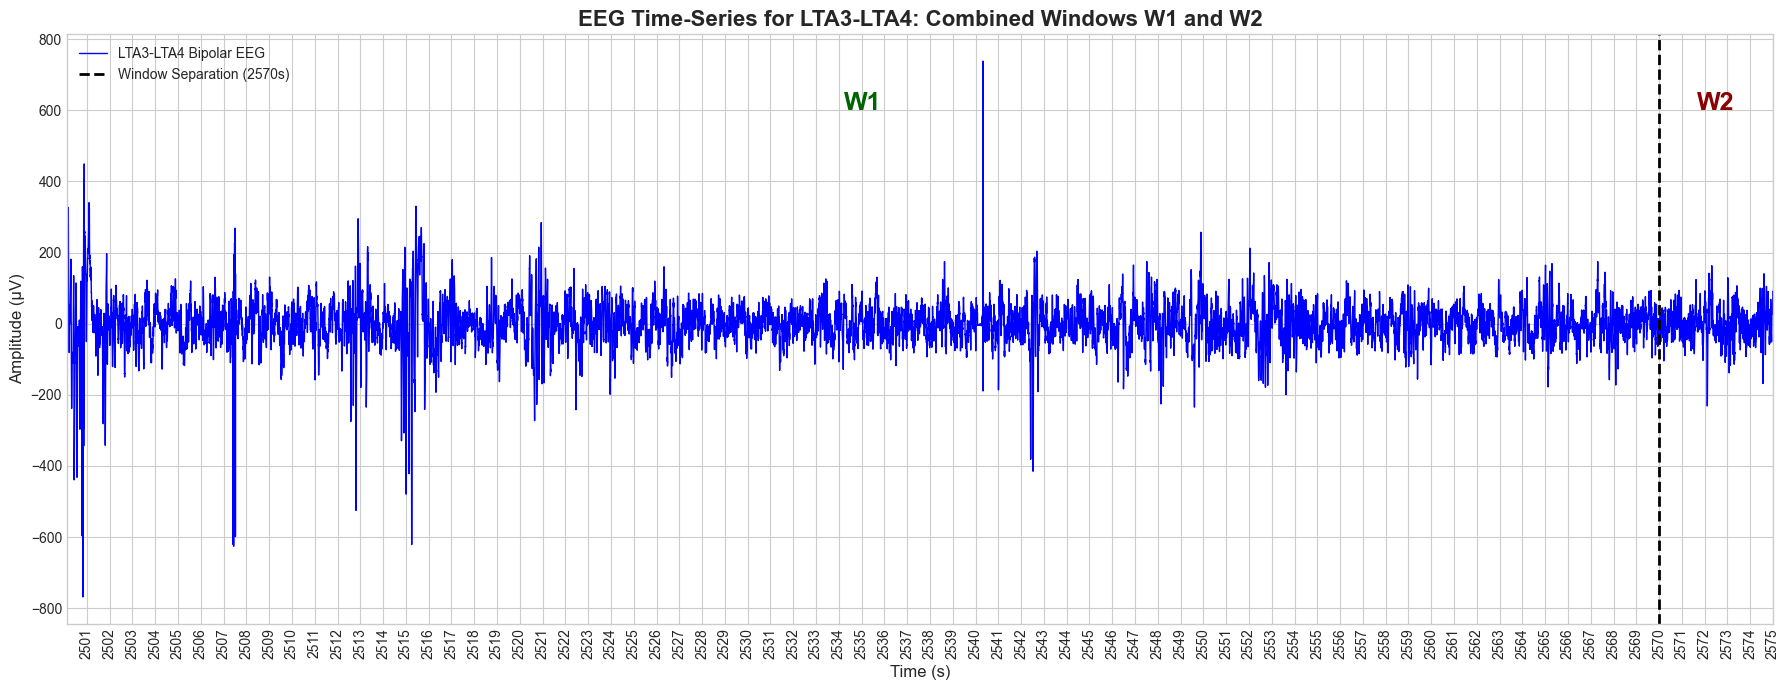

In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker # Import the ticker module
import numpy as np # Ensure numpy is imported for concatenation

try:
    # --- Combine time and signal data for a single plot ---
    # It's crucial to concatenate them only if the time points are continuous.
    # Given your problem description (E1_end_s == E2_start_s), this is safe.
    combined_time = np.concatenate((e1_time, e2_time))
    combined_signal = np.concatenate((e1_signal, e2_signal))

    # Determine the full range for the x-axis
    full_start_time = e1_start_s
    full_end_time = e2_end_s
    
    # The separation point is where E1 ends and E2 begins
    separation_time = e1_end_s # This is 2570.00 seconds

    # Set a professional plot style
    plt.style.use('seaborn-v0_8-whitegrid')

    # Create a single figure and axes
    fig, ax = plt.subplots(
        nrows=1, 
        ncols=1, 
        figsize=(18, 7) # Adjust figure size for a single, wider plot
    )

    # --- Plot the combined signal ---
    ax.plot(combined_time, combined_signal, color='blue', linewidth=1, label='LTA3-LTA4 Bipolar EEG')
    ax.set_title('EEG Time-Series for LTA3-LTA4: Combined Windows W1 and W2', fontsize=16, fontweight='bold')
    ax.set_ylabel('Amplitude (µV)', fontsize=12)
    ax.set_xlabel('Time (s)', fontsize=12)
    
    # Set x-axis limits to cover the entire combined duration
    ax.set_xlim(full_start_time, full_end_time) 

    # --- Add the vertical separation line ---
    ax.axvline(separation_time, color='black', linestyle='--', linewidth=2, label='Window Separation (2570s)')

    # --- Add text labels for W1 and W2 ---
    # Position them slightly to the left/right of the separation line
    # Adjust y-position based on your signal amplitude range if needed
    y_text_pos = ax.get_ylim()[1] * 0.8 # Roughly 80% of max amplitude for text height
    
    # Calculate x-position for W1 text (midpoint of W1)
    x_pos_w1 = (e1_start_s + separation_time) / 2
    ax.text(x_pos_w1, y_text_pos, 'W1', 
            fontsize=18, fontweight='bold', color='darkgreen', 
            ha='center', va='top')

    # Calculate x-position for W2 text (midpoint of W2)
    x_pos_w2 = (separation_time + e2_end_s) / 2
    ax.text(x_pos_w2, y_text_pos, 'W2', 
            fontsize=18, fontweight='bold', color='darkred', 
            ha='center', va='top')

    # --- Apply 1-second vertical tick formatting to the single plot ---
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.tick_params(axis='x', rotation=90, labelsize=10)
    
    # Add a legend to explain the line
    ax.legend(fontsize=10)

    plt.tight_layout()
    
    # Save the figure
    plt.savefig('EEG_LTA3-LTA4_Combined_W1_W2.png', dpi=300) 
    
    plt.show()

except NameError:
    print("Error: Cannot plot. Ensure the data for E1 and E2 was extracted correctly.")
except Exception as e:
    print(f"An unexpected error occurred during plotting: {e}")

Generating plot with ALL 97 Channel Names on Y-axis...


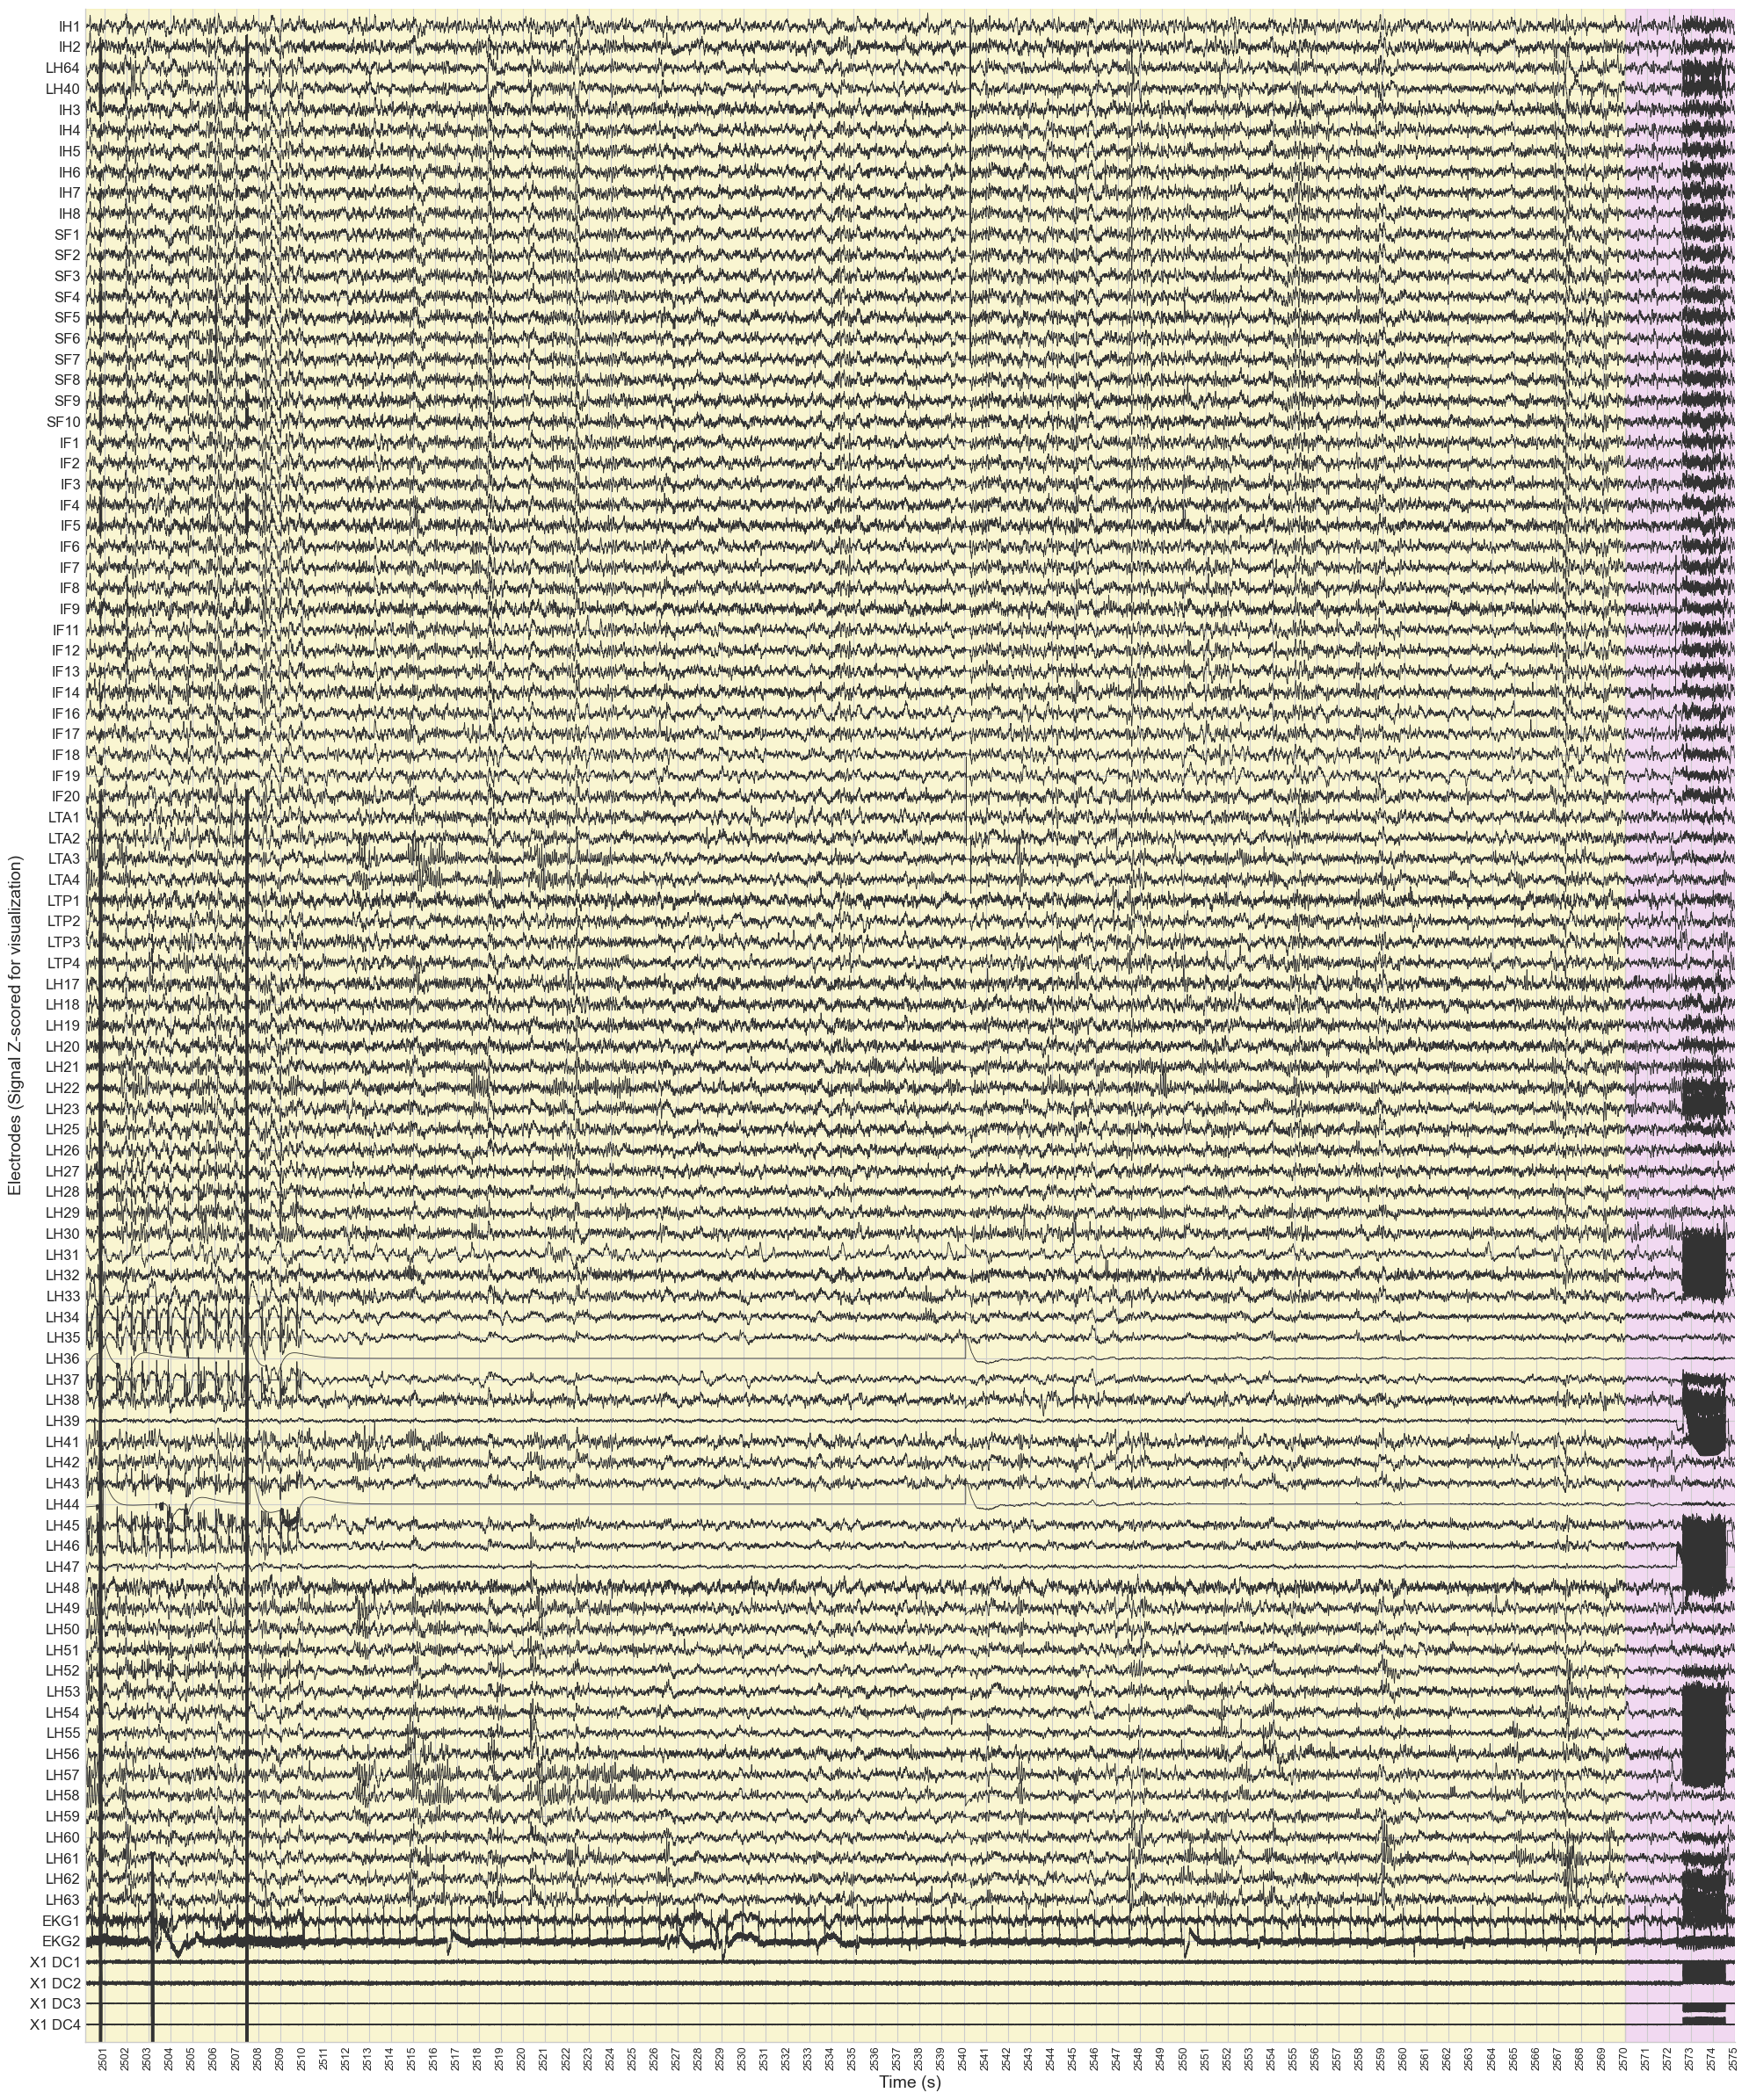

<Figure size 640x480 with 0 Axes>

In [7]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

print("Generating plot with ALL 97 Channel Names on Y-axis...")

try:
    # --- 1. Define Window Boundaries and Slice Data ---
    w1_start_s = 2500.12
    w1_end_s = 2570.00
    w2_end_s = 2575.00
    
    combined_indices = np.where((time >= w1_start_s) & (time <= w2_end_s))
    sliced_time = time[combined_indices]
    sliced_signals = signals[:, combined_indices[0]]
    num_channels = sliced_signals.shape[0]

    # --- 2. Normalize Each Channel (Z-SCORE) ---
    mean_per_channel = np.mean(sliced_signals, axis=1, keepdims=True)
    std_per_channel = np.std(sliced_signals, axis=1, keepdims=True)
    std_per_channel[std_per_channel == 0] = 1 
    scaled_signals = (sliced_signals - mean_per_channel) / std_per_channel

    # --- 3. Create the Multi-Channel Plot ---
    VERTICAL_OFFSET = 6 
    fig, ax = plt.subplots(figsize=(20, 24))

    ax.axvspan(w1_start_s, w1_end_s, color='khaki', alpha=0.4, zorder=0)
    ax.axvspan(w1_end_s, w2_end_s, color='plum', alpha=0.4, zorder=0)

    for i in range(num_channels):
        vertical_position = i * VERTICAL_OFFSET
        ax.plot(sliced_time, scaled_signals[i, :] + vertical_position, 
                color='#333333',
                linewidth=0.6)

    # --- 4. Format the Plot with Requested Changes ---
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel('Electrodes (Signal Z-scored for visualization)', fontsize=14)
    
    # --- CHANGE 1: Set label interval to 1 ---
    # This will create a label for every single channel.
    label_interval = 1 
    y_tick_indices = np.arange(0, num_channels, label_interval)
    y_tick_positions = y_tick_indices * VERTICAL_OFFSET
    ax.set_yticks(y_tick_positions)
    ax.set_yticklabels(channel_names[::label_interval]) 
    
    # --- CHANGE 2: Reduce font size for Y-axis labels ---
    # This is necessary to prevent the 97 labels from overlapping completely.
    ax.tick_params(axis='y', labelsize=12) 
    
    ax.invert_yaxis()
    ax.set_ylim(((num_channels -1) * VERTICAL_OFFSET + 5), (-5))

    # X-axis formatting remains the same
    ax.set_xlabel('Time (s)', fontsize=14)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.tick_params(axis='x', rotation=90, labelsize=9)
    ax.set_xlim(w1_start_s, w2_end_s)
    
    plt.tight_layout()
    plt.savefig('iEEG_All_97_Named_Channels.png', dpi=300)
    plt.show()
    plt.savefig("my_plot.png")


except NameError:
    print("Error: Make sure 'signals', 'time', and 'channel_names' were loaded correctly.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

